# Impact comparison
<!-- markdownlint-disable MD013 -->

Check that:

- rainfall is good predictor of flood extent
- flood extent is good predictor of impact
- CERF/CBPF allocations are well-matched with impact

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [575]:
import calendar

import ocha_stratus as stratus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from src.constants import *
from src.datasources import era5, seas5

## Load data

### Exposure

In [3]:
pcode = "SS"
query = f"SELECT * FROM app.floodscan_exposure WHERE pcode = '{pcode}'"

In [4]:
df_exp_daily = pd.read_sql(
    query, stratus.get_engine(stage="prod"), parse_dates=["valid_date"]
)

In [418]:
df_exp_yearly = (
    df_exp_daily.groupby(df_exp_daily["valid_date"].dt.year)["sum"]
    .agg(["mean", "max", "min"])
    .reset_index()
)
df_exp_yearly["max_diff"] = df_exp_yearly["max"] - df_exp_yearly["min"]
df_exp_yearly["mean_diff"] = df_exp_yearly["mean"] - df_exp_yearly["min"]

In [421]:
df_exp_yearly["max_prev"] = df_exp_yearly["max"].shift()
df_exp_yearly["mean_prev"] = df_exp_yearly["mean"].shift()

In [422]:
window = 3
df_exp_yearly[f"mean_roll{window}"] = (
    df_exp_yearly["mean"].rolling(window).mean()
)
df_exp_yearly[f"max_diff_mean_roll{window}"] = (
    df_exp_yearly["max"] / df_exp_yearly[f"mean_roll{window}"]
)

<Axes: xlabel='valid_date'>

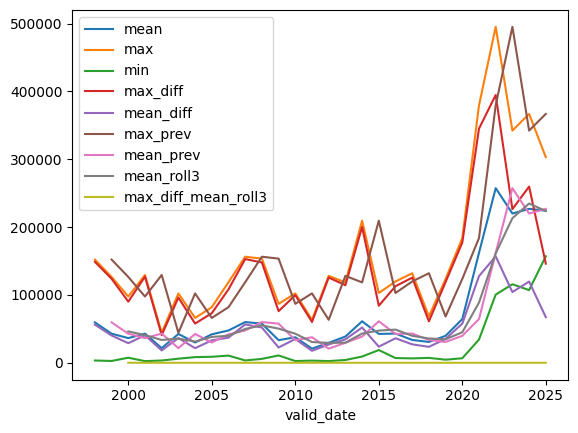

In [423]:
df_exp_yearly.set_index("valid_date").plot()

In [424]:
df_exp_yearly = df_exp_yearly.rename(
    columns={
        x: f"{x}_exp"
        for x in df_exp_yearly.columns
        if x != "valid_date" and "exp" not in x
    }
)

In [425]:
df_exp_yearly

,valid_date,mean_exp,max_exp,min_exp,max_diff_exp,mean_diff_exp,max_prev_exp,mean_prev_exp,mean_roll3_exp,max_diff_mean_roll3_exp
0,1998,59556.785311,152155.0,3343.0,148812.0,56213.785311,NaN,NaN,NaN,NaN
1,1999,42893.224658,126544.0,2663.0,123881.0,40230.224658,152155.0,59556.785311,NaN,NaN
2,2000,36362.508197,97660.0,7472.0,90188.0,28890.508197,126544.0,42893.224658,46270.839388,2.110617
3,2001,43013.652055,129377.0,2423.0,126954.0,40590.652055,97660.0,36362.508197,40756.461636,3.174392
4,2002,21579.810959,44173.0,3374.0,40799.0,18205.810959,129377.0,43013.652055,33651.990403,1.312642
5,2003,42480.830137,102194.0,6037.0,96157.0,36443.830137,44173.0,21579.810959,35691.431050,2.863264
6,2004,29861.836066,66140.0,8338.0,57802.0,21523.836066,102194.0,42480.830137,31307.492387,2.112593
7,2005,41970.375342,81974.0,8870.0,73104.0,33100.375342,66140.0,29861.836066,38104.347182,2.151303
8,2006,47637.558904,118770.0,10580.0,108190.0,37057.558904,81974.0,41970.375342,39823.256771,2.982428
9,2007,60032.915068,156370.0,3439.0,152931.0,56593.915068,118770.0,47637.558904,49880.283105,3.134906


### SEAS5

Load and filter SEAS5 data to specific `issued_month`.

In [13]:
df_seas5_all = seas5.load_seas5(pcode=pcode)

In [227]:
issued_month = 4
issued_mo_str = calendar.month_abbr[issued_month]
df_seas5_imo = df_seas5_all[
    df_seas5_all["issued_date"].dt.month == issued_month
]

In [228]:
valid_months = sorted(df_seas5_imo["valid_date"].dt.month.unique())
valid_mo_str = "".join([calendar.month_abbr[x][0] for x in valid_months])
valid_mo_str

'AMJJASO'

In [229]:
df_seas5_yearly = (
    df_seas5_imo.groupby(df_seas5_imo["valid_date"].dt.year)["mean"]
    .mean()
    .reset_index()
)

In [230]:
def detrend_column(
    df: pd.DataFrame, col: str, index_col: str = "valid_date"
) -> pd.DataFrame:
    """
    Detrend a column in a DataFrame using linear regression (via NumPy).

    Parameters:
    -----------
    df : pd.DataFrame
        The input DataFrame. Must contain a datetime column.
    col : str
        The name of the column to detrend.
    time_col : str
        The name of the datetime column. Default is "valid_date".

    Returns:
    --------
    pd.DataFrame
        Copy of the input DataFrame with a new column: <col>_detrended
    """
    df_sorted = df.sort_values(index_col).copy()

    # Convert datetime to numeric (days since min)
    x = df_sorted[index_col]
    y = df_sorted[col].values

    # Linear regression fit
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]

    trend = a * x + b
    detrended = y - trend
    detrended += y.mean()  # Shift to preserve original mean

    df_sorted[f"{col}_detrended"] = detrended

    return df_sorted

In [231]:
df_seas5_yearly = detrend_column(df_seas5_yearly, col="mean")

<Axes: xlabel='valid_date'>

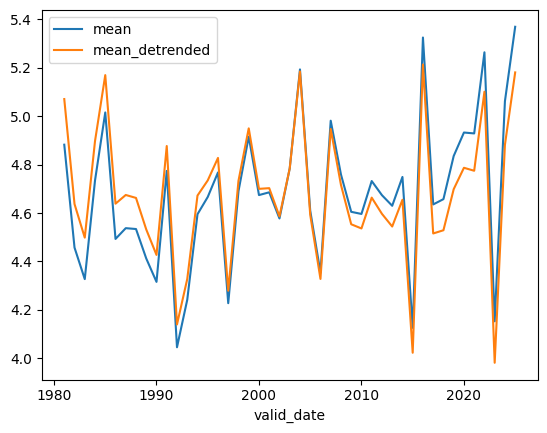

In [232]:
df_seas5_yearly.set_index("valid_date").plot()

In [233]:
df_seas5_yearly

,valid_date,mean,mean_detrended
0,1981,4.881939,5.070289
1,1982,4.457162,4.636950
2,1983,4.326990,4.498217
3,1984,4.734103,4.896769
4,1985,5.015047,5.169152
5,1986,4.492831,4.638374
6,1987,4.537360,4.674342
7,1988,4.533793,4.662213
8,1989,4.412129,4.531988
9,1990,4.315574,4.426872


### ERA5

Load and filter ERA5 data to same `valid_months` as SEAS5.

In [234]:
df_era5 = era5.load_era5(pcode=pcode)

In [235]:
df_era5_yearly = (
    df_era5[df_era5["valid_date"].dt.month.isin(valid_months)]
    .groupby(df_era5["valid_date"].dt.year)["mean"]
    .mean()
    .reset_index()
)
df_era5_yearly = df_era5_yearly[df_era5_yearly["valid_date"] < 2025]

In [236]:
df_era5_yearly = detrend_column(df_era5_yearly, "mean")

<Axes: xlabel='valid_date'>

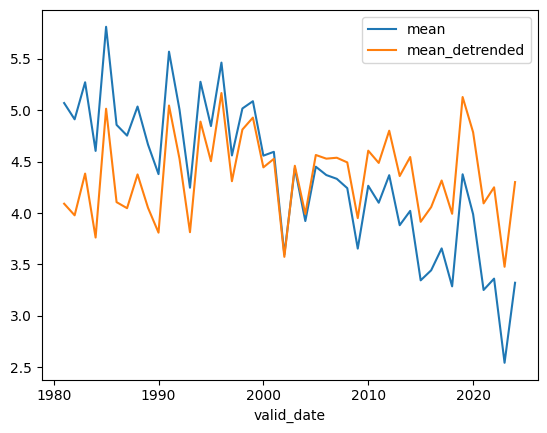

In [237]:
df_era5_yearly.set_index("valid_date").plot()

### EM-DAT

In [238]:
blob_name = f"{PROJECT_PREFIX}/raw/emdat/emdat_ssd_flooding_2025-04-17.csv"
df_emdat_events = stratus.load_csv_from_blob(blob_name)

In [340]:
df_emdat_yearly = (
    df_emdat_events.groupby("Start Year")["Total Affected"].sum().reset_index()
)

In [345]:
# Ensure Start Year is the index
df_emdat_yearly = df_emdat_yearly.set_index("Start Year")

# Reindex to fill in all years 2000–2024
df_emdat_yearly = df_emdat_yearly.reindex(range(2000, 2025), fill_value=0)

# Reset index if you want to plot with "Start Year" as a column
df_emdat_yearly = df_emdat_yearly.reset_index().rename(
    columns={"index": "Start Year"}
)
df_emdat_yearly["Total Affected"] = df_emdat_yearly["Total Affected"].astype(
    int
)

In [346]:
df_emdat_yearly

,Start Year,Total Affected
0,2000,0
1,2001,0
2,2002,0
3,2003,0
4,2004,0
5,2005,0
6,2006,0
7,2007,0
8,2008,92791
9,2009,0


<Axes: xlabel='Start Year'>

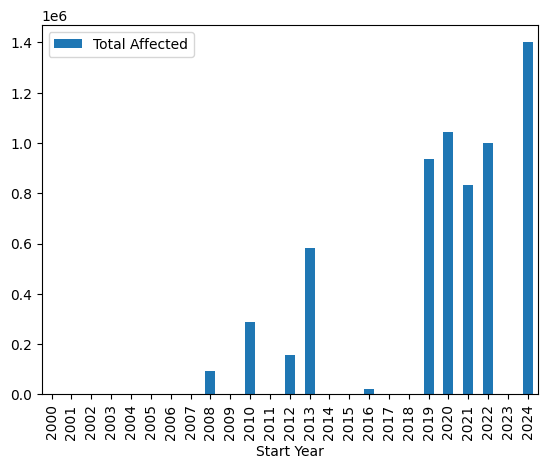

In [342]:
df_emdat_yearly.plot(x="Start Year", y="Total Affected", kind="bar")

## Combine

In [426]:
df_compare_full = (
    df_exp_yearly.merge(
        df_era5_yearly.rename(
            columns={
                "mean": "mean_era5",
                "mean_detrended": "mean_era5_detrended",
            }
        ),
        how="outer",
    )
    .merge(
        df_seas5_yearly,
        how="outer",
    )
    .rename(
        columns={
            "mean": "mean_seas5",
            "mean_detrended": "mean_seas5_detrended",
        }
    )
    .merge(
        df_emdat_yearly.rename(
            columns={
                "Start Year": "valid_date",
                "Total Affected": "total_affected",
            }
        ),
        how="outer",
    )
).rename(columns={"valid_date": "year"})
df_compare_full["cerf"] = df_compare_full["year"].isin(CERF_YEARS)
df_compare = df_compare_full[
    (df_compare_full["year"] < 2025) & (df_compare_full["year"] >= 2000)
].copy()
df_compare

,year,mean_exp,max_exp,min_exp,max_diff_exp,mean_diff_exp,max_prev_exp,mean_prev_exp,mean_roll3_exp,max_diff_mean_roll3_exp,mean_era5,mean_era5_detrended,mean_seas5,mean_seas5_detrended,total_affected,cerf
19,2000,36362.508197,97660.0,7472.0,90188.0,28890.508197,126544.0,42893.224658,46270.839388,2.110617,4.557891,4.444011,4.673926,4.699610,0.0,False
20,2001,43013.652055,129377.0,2423.0,126954.0,40590.652055,97660.0,36362.508197,40756.461636,3.174392,4.595214,4.526885,4.685367,4.702490,0.0,False
21,2002,21579.810959,44173.0,3374.0,40799.0,18205.810959,129377.0,43013.652055,33651.990403,1.312642,3.596384,3.573608,4.577389,4.585951,0.0,False
22,2003,42480.830137,102194.0,6037.0,96157.0,36443.830137,44173.0,21579.810959,35691.431050,2.863264,4.436530,4.459306,4.784031,4.784031,0.0,False
23,2004,29861.836066,66140.0,8338.0,57802.0,21523.836066,102194.0,42480.830137,31307.492387,2.112593,3.921729,3.990057,5.192686,5.184125,0.0,False
24,2005,41970.375342,81974.0,8870.0,73104.0,33100.375342,66140.0,29861.836066,38104.347182,2.151303,4.450388,4.564269,4.609769,4.592646,0.0,False
25,2006,47637.558904,118770.0,10580.0,108190.0,37057.558904,81974.0,41970.375342,39823.256771,2.982428,4.369282,4.528714,4.353419,4.327735,0.0,False
26,2007,60032.915068,156370.0,3439.0,152931.0,56593.915068,118770.0,47637.558904,49880.283105,3.134906,4.332578,4.537562,4.980929,4.946684,0.0,False
27,2008,57716.191257,153533.0,5749.0,147784.0,51967.191257,156370.0,60032.915068,55128.888410,2.784983,4.241685,4.492222,4.758863,4.716056,92791.0,False
28,2009,33345.947945,86897.0,10816.0,76081.0,22529.947945,153533.0,57716.191257,50365.018090,1.725344,3.653909,3.949998,4.604791,4.553423,0.0,False


In [427]:
df_compare_full

,year,mean_exp,max_exp,min_exp,max_diff_exp,mean_diff_exp,max_prev_exp,mean_prev_exp,mean_roll3_exp,max_diff_mean_roll3_exp,mean_era5,mean_era5_detrended,mean_seas5,mean_seas5_detrended,total_affected,cerf
0,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.069735,4.090363,4.881939,5.070289,NaN,False
1,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.911337,3.977518,4.457162,4.636950,NaN,False
2,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.271767,4.383500,4.326990,4.498217,NaN,False
3,1984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.604061,3.761346,4.734103,4.896769,NaN,False
4,1985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.811469,5.014307,5.015047,5.169152,NaN,False
5,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.857398,4.105788,4.492831,4.638374,NaN,False
6,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.752876,4.046818,4.537360,4.674342,NaN,False
7,1988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.035708,4.375202,4.533793,4.662213,NaN,False
8,1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.664949,4.049995,4.412129,4.531988,NaN,False
9,1990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.378200,3.808798,4.315574,4.426872,NaN,False


## Analysis

### Correlations

In [428]:
df_compare.set_index("year").corr()

,mean_exp,max_exp,min_exp,max_diff_exp,mean_diff_exp,max_prev_exp,mean_prev_exp,mean_roll3_exp,max_diff_mean_roll3_exp,mean_era5,mean_era5_detrended,mean_seas5,mean_seas5_detrended,total_affected,cerf
mean_exp,1.000000,0.959560,0.953307,0.884003,0.961809,0.882305,0.891671,0.936750,-0.051598,-0.600381,-0.267855,0.208442,0.071067,0.597188,0.607755
max_exp,0.959560,1.000000,0.845294,0.978483,0.985869,0.776937,0.757924,0.825612,0.202780,-0.517704,-0.126020,0.286377,0.143157,0.641184,0.673251
min_exp,0.953307,0.845294,1.000000,0.716867,0.834234,0.943832,0.972415,0.977929,-0.256705,-0.668351,-0.388366,0.060165,-0.072160,0.480670,0.463720
max_diff_exp,0.884003,0.978483,0.716867,1.000000,0.964316,0.649357,0.613509,0.699706,0.363737,-0.417463,-0.014472,0.350460,0.214671,0.651067,0.699456
mean_diff_exp,0.961809,0.985869,0.834234,0.964316,1.000000,0.755504,0.746698,0.824008,0.138457,-0.490438,-0.137062,0.326053,0.195160,0.654715,0.689369
max_prev_exp,0.882305,0.776937,0.943832,0.649357,0.755504,1.000000,0.958229,0.916649,-0.297768,-0.768416,-0.537858,-0.078593,-0.209641,0.348922,0.338060
mean_prev_exp,0.891671,0.757924,0.972415,0.613509,0.746698,0.958229,1.000000,0.978387,-0.349148,-0.679074,-0.444335,-0.024590,-0.147600,0.387043,0.356947
mean_roll3_exp,0.936750,0.825612,0.977929,0.699706,0.824008,0.916649,0.978387,1.000000,-0.274989,-0.632162,-0.349573,0.087541,-0.041704,0.505655,0.468451
max_diff_mean_roll3_exp,-0.051598,0.202780,-0.256705,0.363737,0.138457,-0.297768,-0.349148,-0.274989,1.000000,0.300660,0.591192,0.188077,0.147588,0.259965,0.266642
mean_era5,-0.600381,-0.517704,-0.668351,-0.417463,-0.490438,-0.768416,-0.679074,-0.632162,0.300660,1.000000,0.773618,0.061884,0.214076,-0.206833,-0.227197


<Axes: >

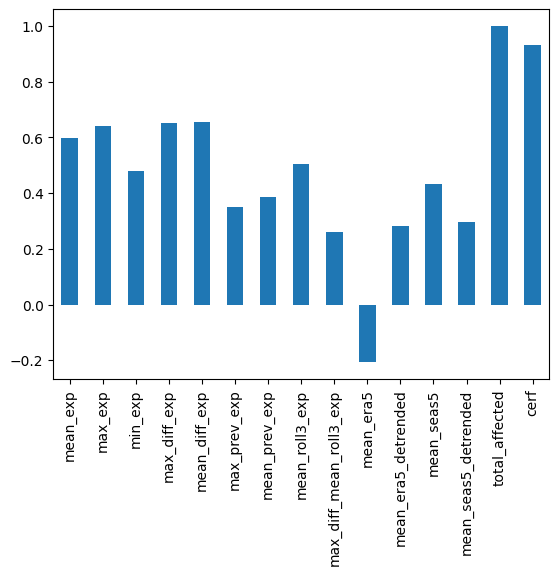

In [468]:
df_compare.set_index("year").corr()["total_affected"].plot(kind="bar")

<Axes: >

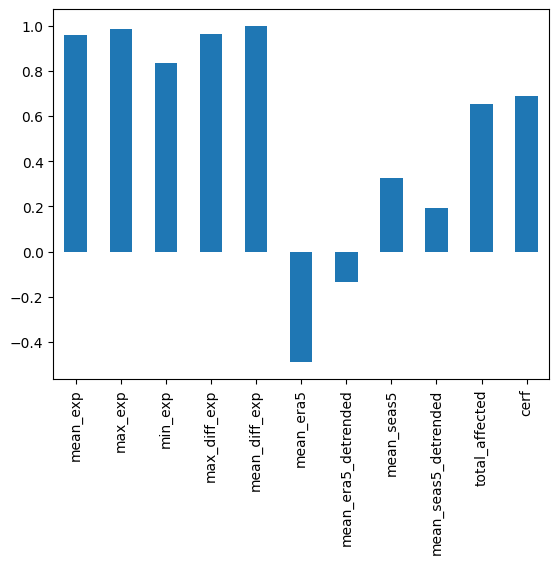

In [256]:
df_compare.set_index("year").corr()["mean_diff_exp"].plot(kind="bar")

<Axes: >

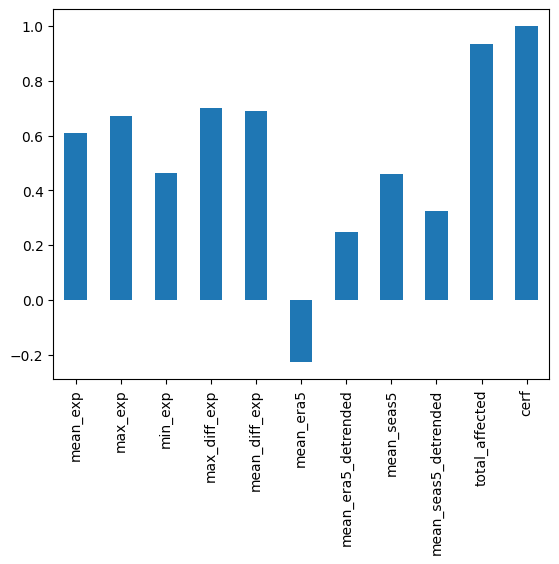

In [257]:
df_compare.set_index("year").corr()["cerf"].plot(kind="bar")

### Plotting

In [453]:
def plot_comparison(df, xcol, ycol, sizecol=None, labels=None, rotation=0):
    df = df.copy()
    fig, ax = plt.subplots(dpi=200, figsize=(7, 7))

    # Replace NaN sizes with a small value
    if sizecol is None:
        sizes = np.full(len(df), 0)
    else:
        sizes = df[sizecol].fillna(0) / df[sizecol].max() * 1000

    # Set colors based on cerf
    df["color"] = df["cerf"].map({True: "crimson", False: "royalblue"})

    scatter = ax.scatter(
        df[xcol], df[ycol], s=sizes, c=df["color"], alpha=0.5, edgecolor="none"
    )

    # Annotate year on each point
    for year, row in df.set_index("year").iterrows():
        ax.annotate(
            str(year),
            (row[xcol], row[ycol]),
            fontsize=8,
            ha="center",
            va="center",
            color=row["color"],
            rotation=rotation,
        )

    if labels is None:
        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)
        ax.set_title("")
    else:
        ax.set_xlabel(labels["x"])
        ax.set_ylabel(labels["y"])
        ax.set_title(labels["title"])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return fig, ax

(<Figure size 1400x1400 with 1 Axes>,
 <Axes: title={'center': 'Impact vs. exposure comparison'}, xlabel='Average adjusted flood exposure during year [Floodscan]', ylabel='Total people affected during year [EM-DAT]'>)

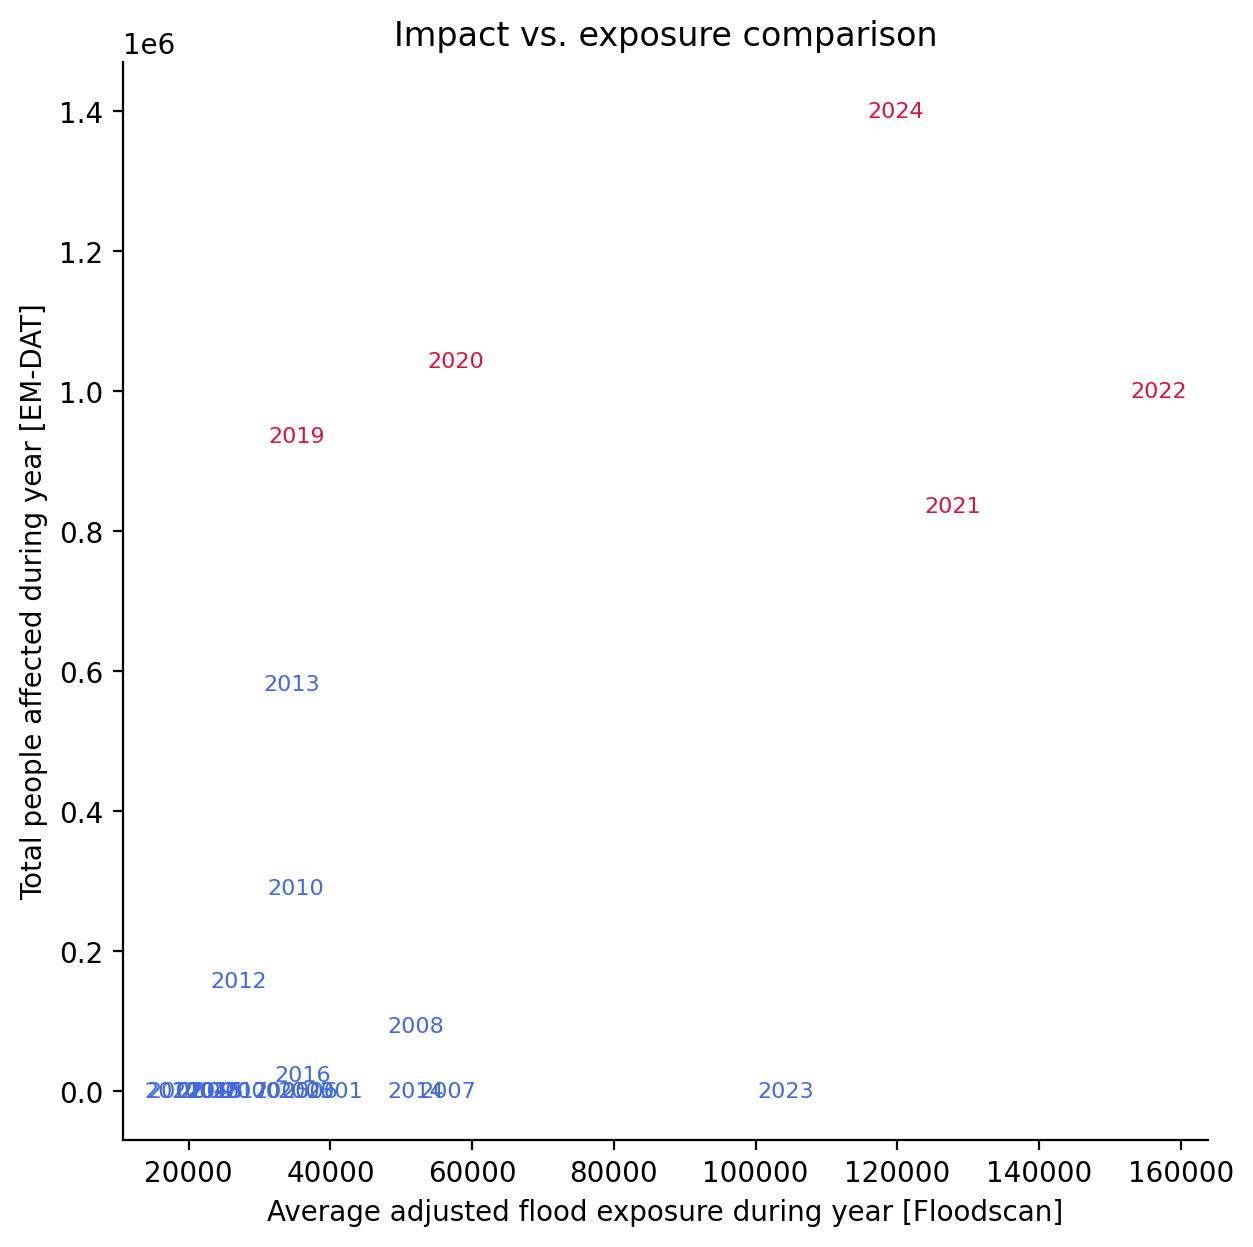

In [259]:
plot_comparison(
    df_compare,
    "mean_diff_exp",
    "total_affected",
    labels={
        "x": "Average adjusted flood exposure during year [Floodscan]",
        "y": "Total people affected during year [EM-DAT]",
        "title": "Impact vs. exposure comparison",
    },
)

(<Figure size 1400x1400 with 1 Axes>,
 <Axes: title={'center': 'Impact vs. exposure comparison'}, xlabel='Average adjusted flood exposure during year [Floodscan]', ylabel='Total people affected during year [EM-DAT]'>)

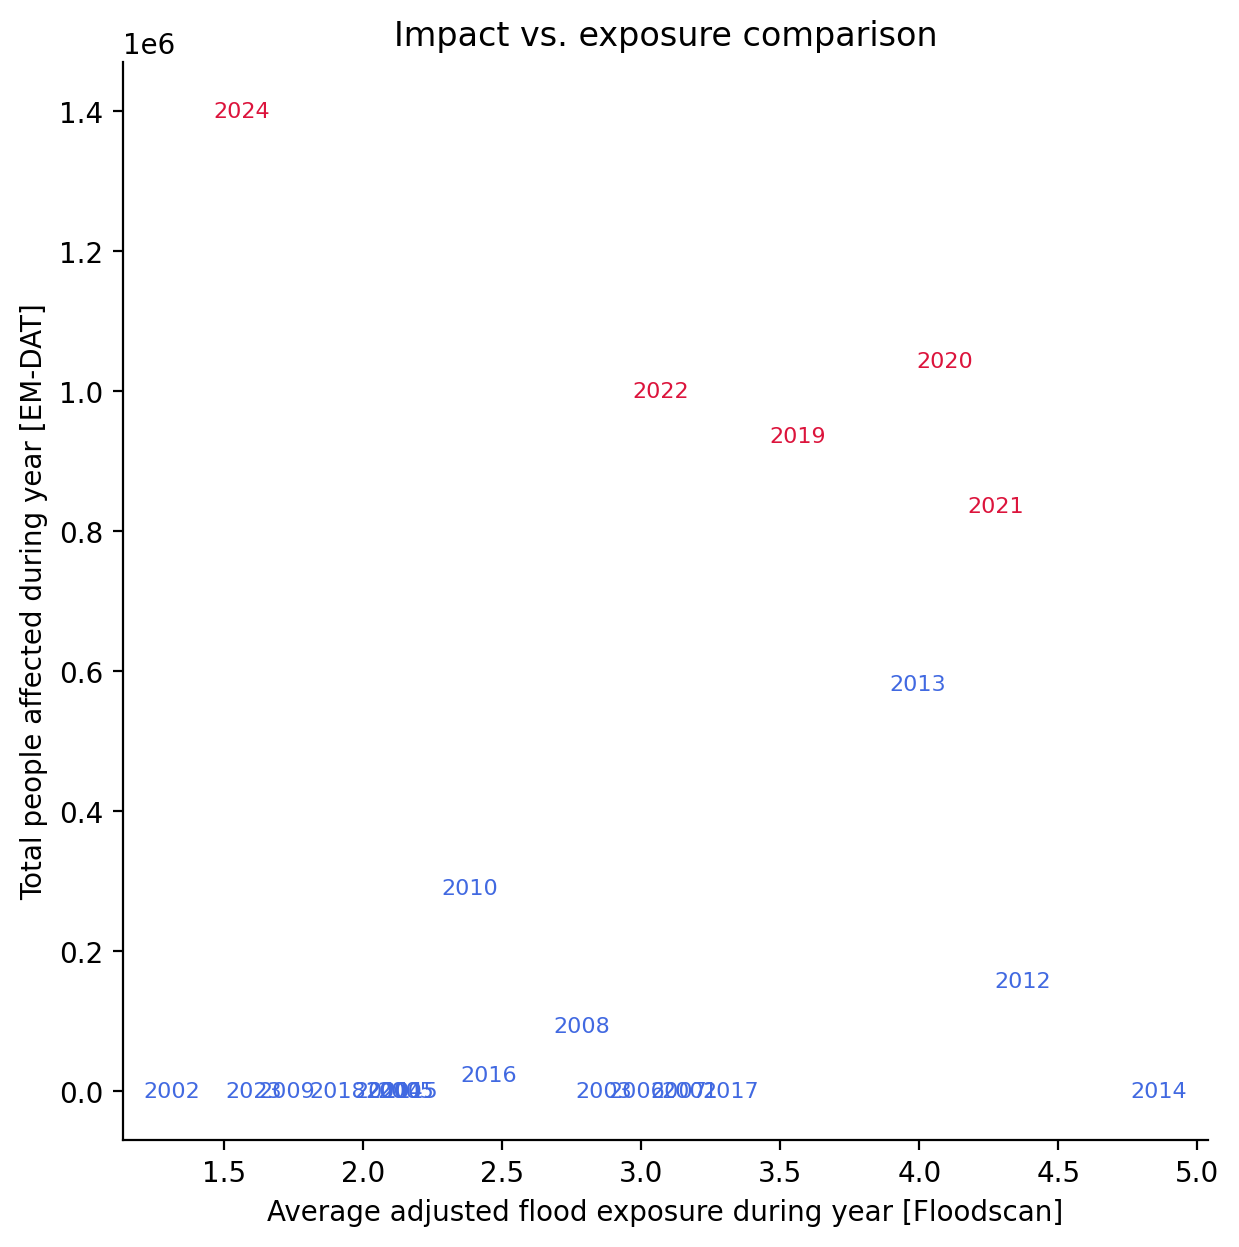

In [280]:
plot_comparison(
    df_compare,
    "max_diff_mean_roll3_exp",
    "total_affected",
    labels={
        "x": "Average adjusted flood exposure during year [Floodscan]",
        "y": "Total people affected during year [EM-DAT]",
        "title": "Impact vs. exposure comparison",
    },
)

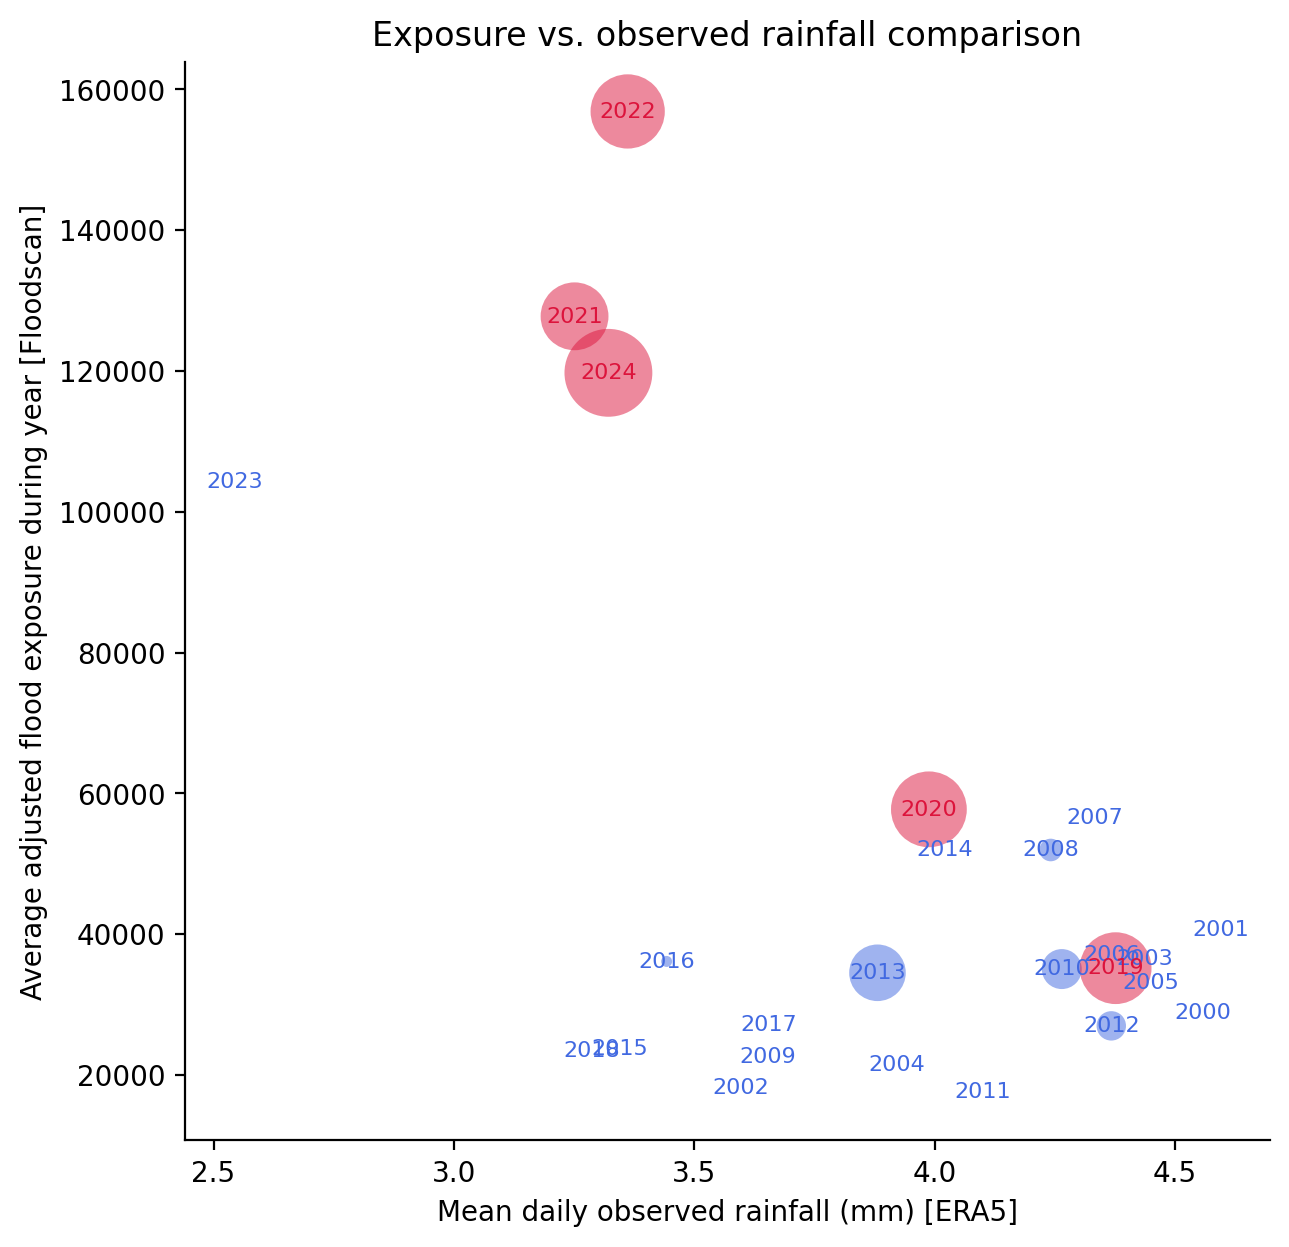

In [260]:
fig, ax = plot_comparison(
    df_compare,
    "mean_era5",
    "mean_diff_exp",
    sizecol="total_affected",
    labels={
        "x": "Mean daily observed rainfall (mm) [ERA5]",
        "y": "Average adjusted flood exposure during year [Floodscan]",
        "title": "Exposure vs. observed rainfall comparison",
    },
)

Text(5.368711057142858, 156878.63287671233, '2025 forecast')

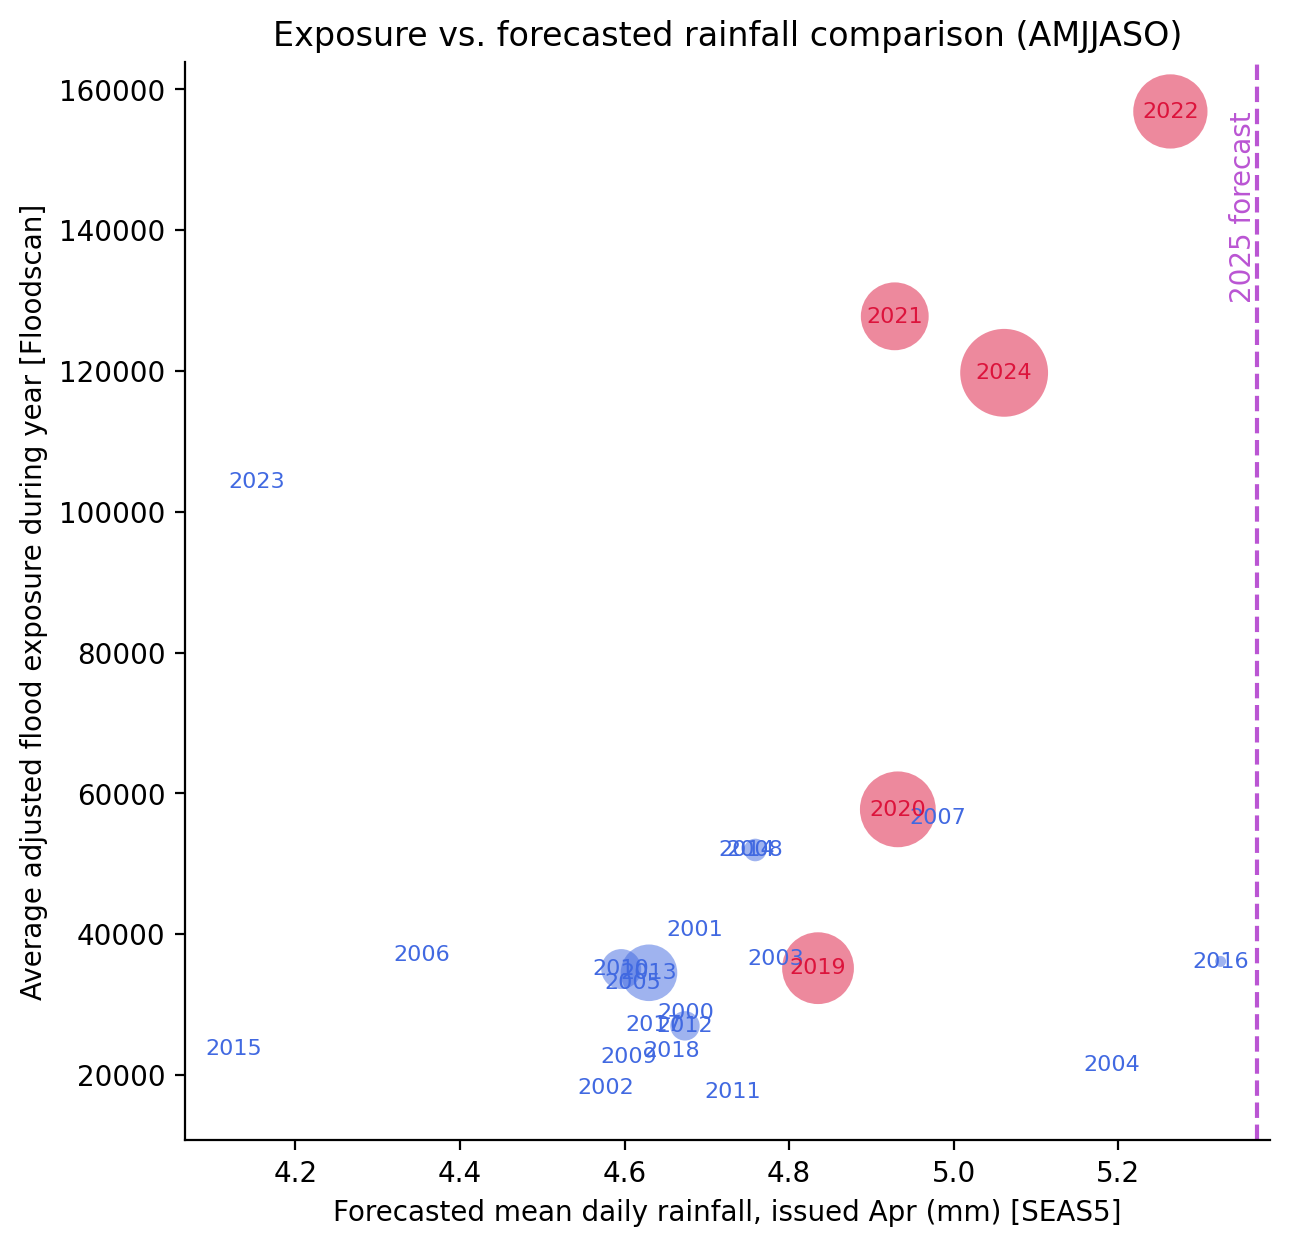

In [261]:
fig, ax = plot_comparison(
    df_compare,
    "mean_seas5",
    "mean_diff_exp",
    sizecol="total_affected",
    labels={
        "x": f"Forecasted mean daily rainfall, issued {issued_mo_str} (mm) [SEAS5]",
        "y": "Average adjusted flood exposure during year [Floodscan]",
        "title": f"Exposure vs. forecasted rainfall comparison ({valid_mo_str})",
    },
)

current_val = df_seas5_yearly.set_index("valid_date").loc[2025]["mean"]

ax.axvline(
    current_val,
    color="mediumorchid",
    linestyle="--",
)
ax.annotate(
    "2025 forecast",
    (current_val, df_compare["mean_diff_exp"].max()),
    rotation=90,
    va="top",
    ha="right",
    color="mediumorchid",
)

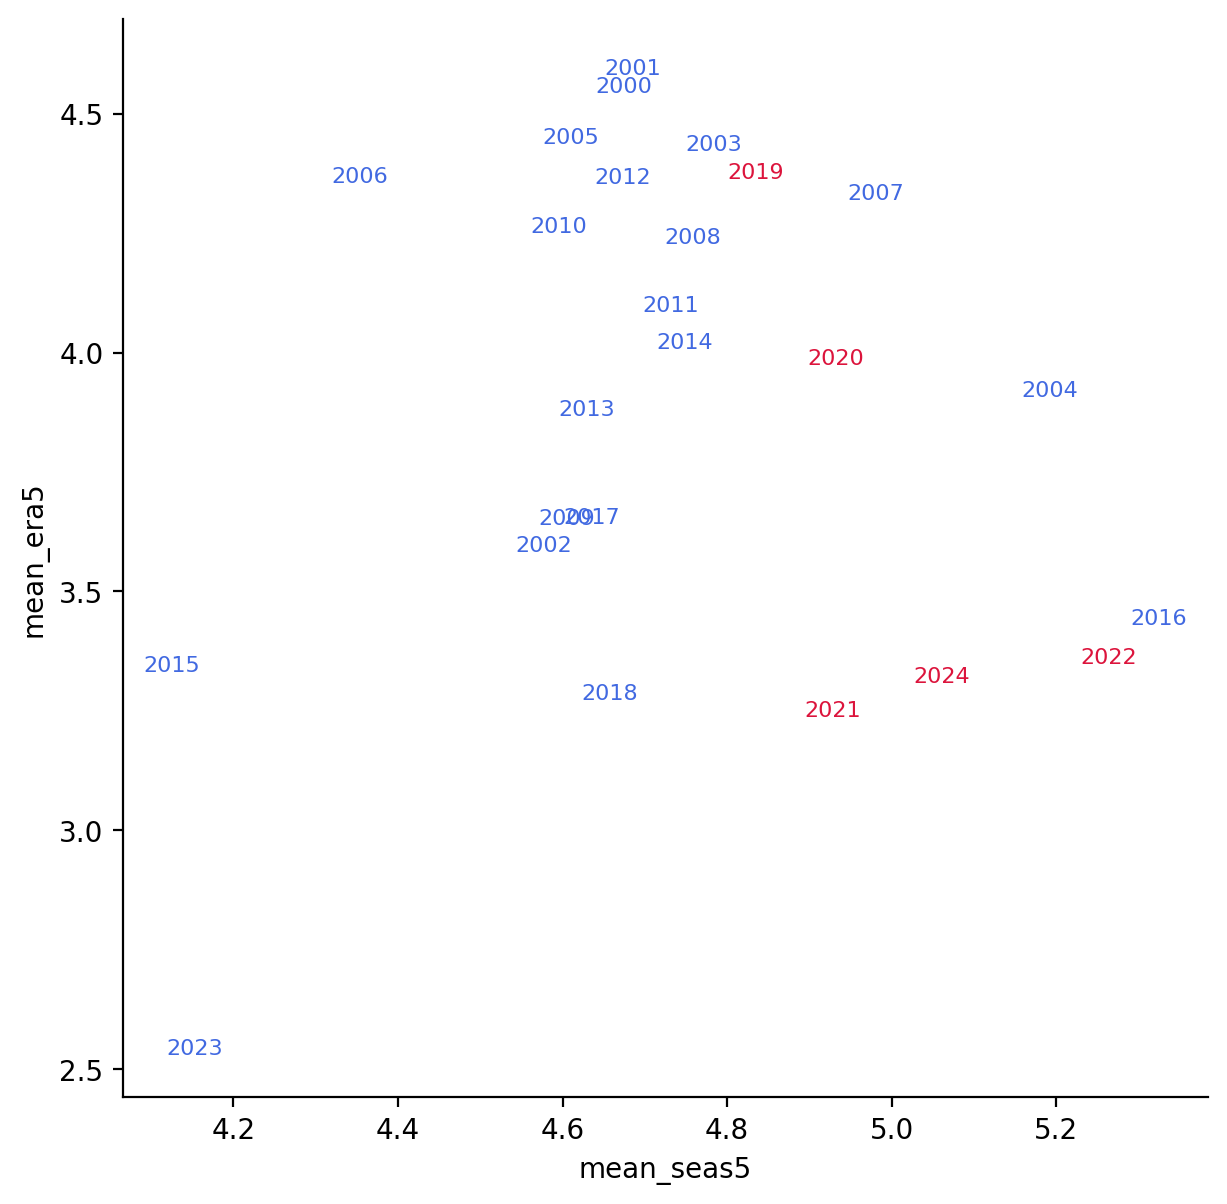

In [262]:
fig, ax = plot_comparison(
    df_compare,
    "mean_seas5",
    "mean_era5",
)

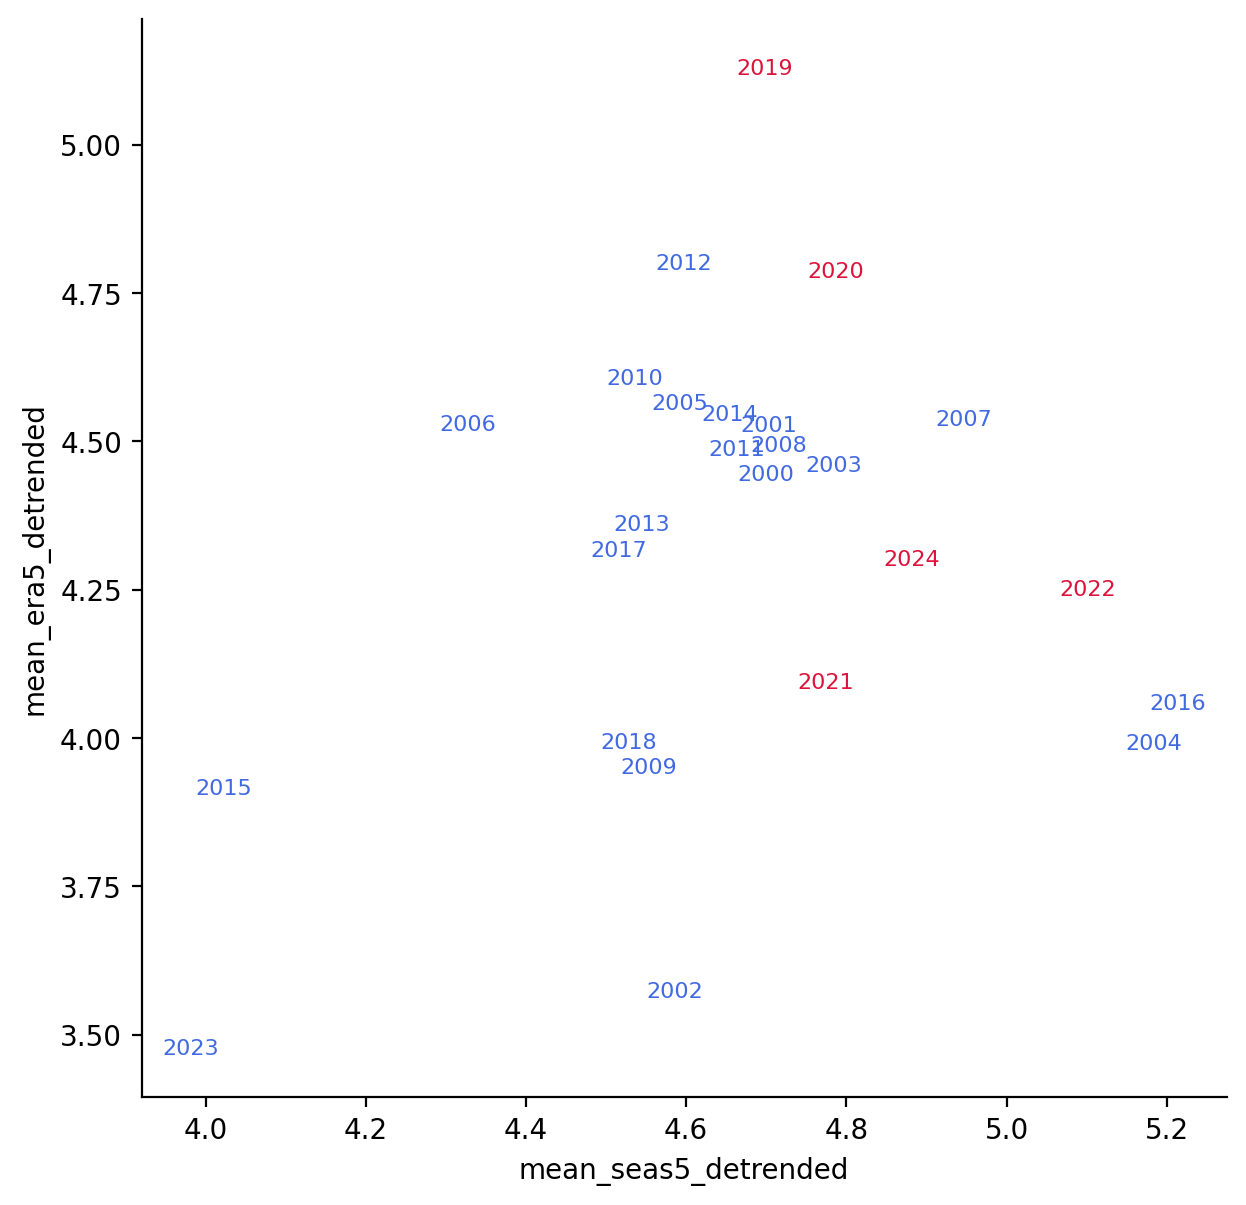

In [263]:
fig, ax = plot_comparison(
    df_compare,
    "mean_seas5_detrended",
    "mean_era5_detrended",
)

## Modeling

In [651]:
df_modeling = df_compare_full.copy()
# df_modeling = df_modeling[
#     (df_modeling["year"] >= 2006) & (df_modeling["year"] < 2025)
# ]
df_modeling["year_dummy"] = (df_modeling["year"] >= 2019).astype(int)

In [652]:
df_modeling.loc[df_modeling["year"] == 2025, "mean_diff_exp"] = np.nan

In [659]:
# Select inputs and output
# input_cols = ["year_dummy", "mean_seas5"]
input_cols = ["min_exp", "mean_seas5"]
output_col = "total_affected"
X = df_modeling[input_cols]
y = df_modeling[output_col]

# Drop rows with missing values
df_clean = pd.concat([X, y], axis=1).dropna()
X = df_clean[input_cols]
y = df_clean[output_col]

# Add constant for intercept
X = sm.add_constant(X)

# Fit linear regression model
model = sm.OLS(y, X).fit()

# Show summary
print(model.summary())

df_modeling["reg_pred"] = model.predict(
    sm.add_constant(df_modeling[input_cols])
)

                            OLS Regression Results                            
Dep. Variable:         total_affected   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     7.190
Date:                Thu, 24 Apr 2025   Prob (F-statistic):            0.00395
Time:                        14:52:22   Log-Likelihood:                -353.02
No. Observations:                  25   AIC:                             712.0
Df Residuals:                      22   BIC:                             715.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.691e+06   1.16e+06     -2.324      0.0

<Axes: >

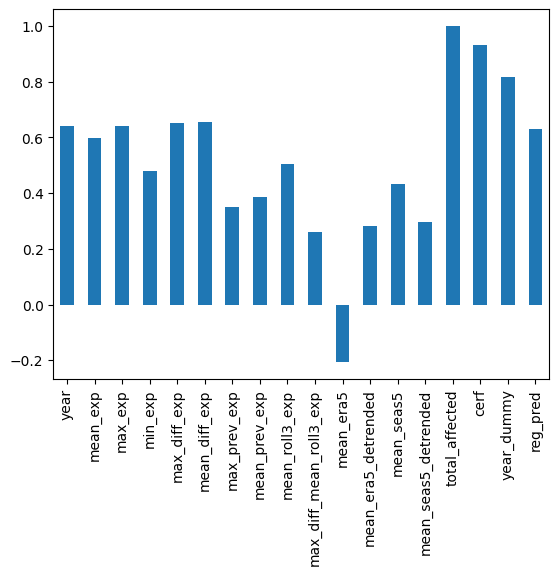

In [660]:
df_modeling.corr()["total_affected"].plot(kind="bar")

Text(0.5, 1.04, 'Variables: Apr SEAS5 forecast, min. exposure during year')

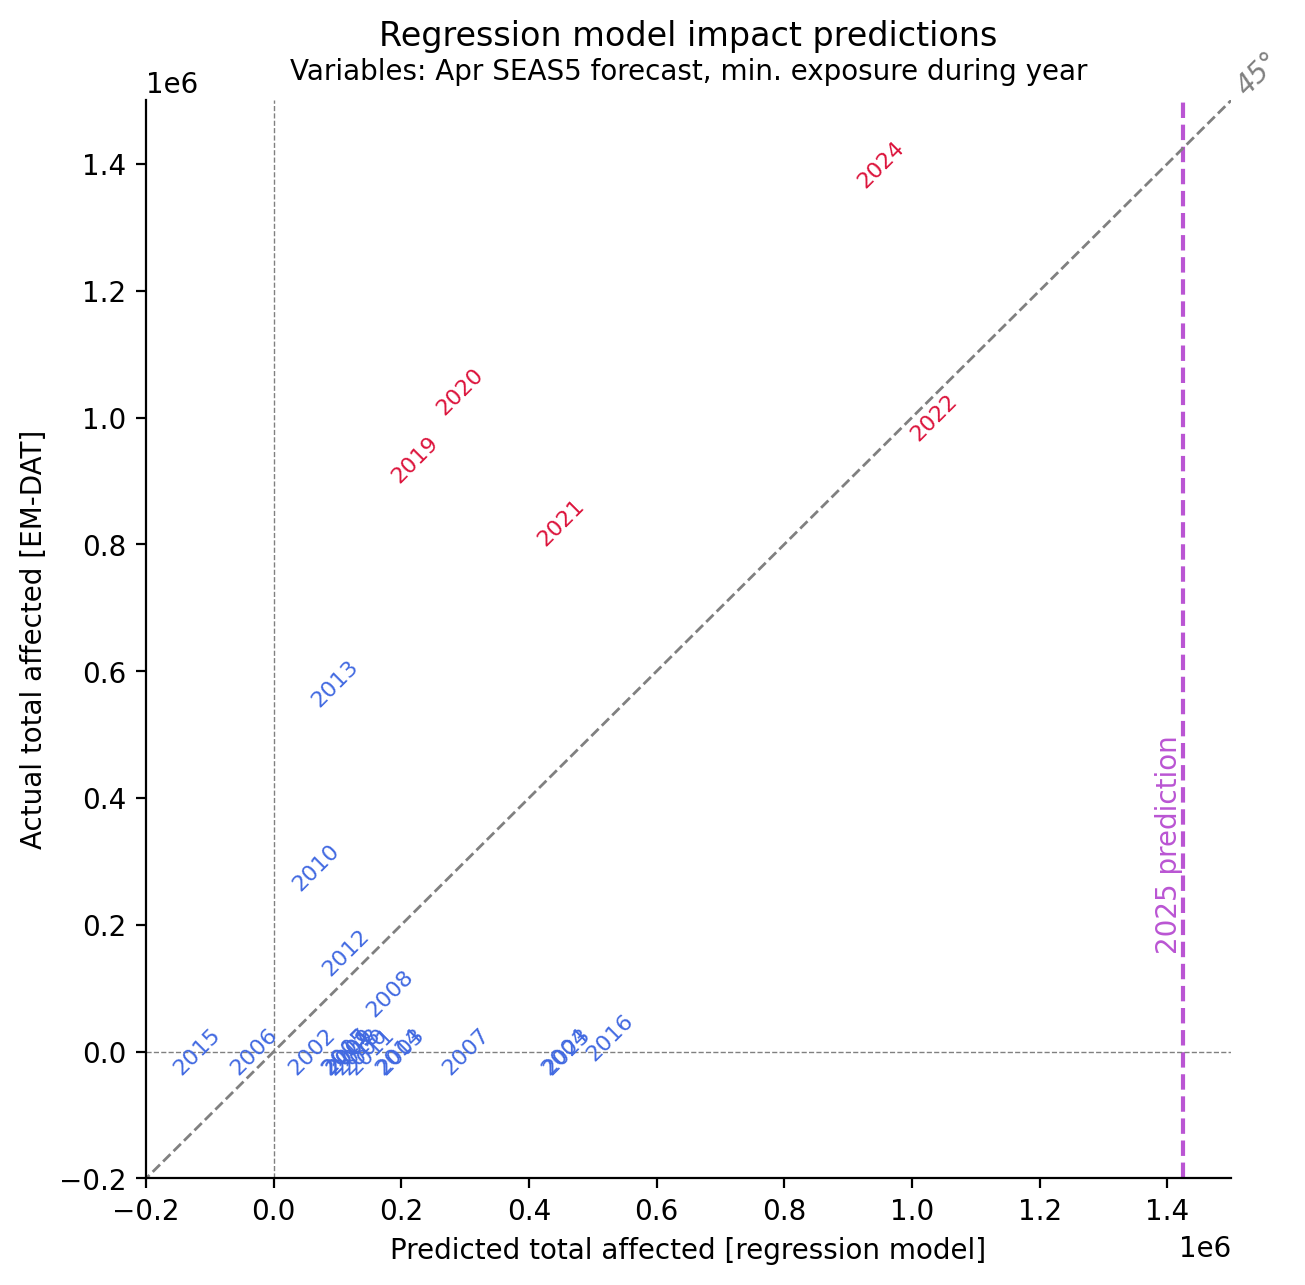

In [662]:
ycol = output_col
xcol = "reg_pred"
fig, ax = plot_comparison(
    df_modeling,
    xcol,
    ycol,
    rotation=45,
)
current_pred = df_modeling.set_index("year").loc[2025, xcol]
ax.axvline(
    current_pred,
    color="mediumorchid",
    linestyle="--",
)
ax.annotate(
    "2025 prediction",
    (current_pred, 0.5e6),
    rotation=90,
    va="top",
    ha="right",
    color="mediumorchid",
)
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.plot([-2e6, 2e6], [-2e6, 2e6], color="grey", linewidth=1, linestyle="--")
ax.annotate(
    "45°",
    (1.5e6, 1.5e6),
    color="grey",
    rotation=45,
    fontstyle="italic",
    va="bottom",
    ha="left",
)
ax.set_ylim([-0.2e6, 1.5e6])
ax.set_xlim([-0.2e6, 1.5e6])

ax.set_ylabel("Actual total affected [EM-DAT]")
ax.set_xlabel("Predicted total affected [regression model]")

ax.set_title("Regression model impact predictions\n")
ax.text(
    0.5,
    1.04,
    # "Variables: Apr SEAS5 forecast, ≥2019 dummy",
    "Variables: Apr SEAS5 forecast, min. exposure during year",
    transform=ax.transAxes,
    ha="center",
    va="top",
)